<!--- Made by:
      Oscar Antonio Restrepo Gutiérrez
--->

# Estadística (técnicas de monte carlo)

1) [Generación de números aleatorios y estadística descriptiva](#números_aleatorios) 
   + distribución uniforme,
   + distribución exponencial decreciente,
   + distribución normal o gaussiana y teorema central del límite,
   + distribución de poisson.

2) [Métodos de monte carlo en física](#Métodos_de_monte_carlo)
   + caminos aleatorios,
   + decaimiento exponencial,
   + procesos de poisson,
   + regresión lineal: mínimos cuadrados,
   + ley de grandes números.

<a id='números_aleatorios'></a>
## Generación de números aleatorios y estadística descriptiva 
### Conceptos de teoria de probabilidad

**La probabilidad** es un concepto que se maneja a diario, en términos generales se puede ver como una cuantificación de nuestra expectativa de obtener un resultado de un evento en un experimento, más cuantitativamente, si en un experimento de $n$ realizaciones ocurren $f_i$ observaciones de un evento $i$, entonces la probabilidad $p_i$ de observar el evento $i$ es,
<!---
más cuantitativamente, suponga que hay $m$ eventos distintos a observar en un experimento y que este se repite $n$ veces, entonces si en el experimento ocurren $f_i$ observaciones de un evento $i$, la probabilidad $p_i$ de observar el evento $i$ es,
--->
$$p_i=\frac{f_i}{n}$$

note que, $\sum_{i=1}^m f_i = n,$ por lo que $\sum_{i=1}^m p_i=1,$ donde $m$ es el número total de distintos eventos a observar, diferente de $n$, el número de repeticiones en el experimento, además como $f_i\leq n$ entonces $0\leq p_i\leq 1$. Se define el valor medio (`np.mean()`) por,

$$
\mu   \equiv \langle x\rangle=\frac{1}{n}\sum_{i=1}^n x_i=\sum_{i=1}^m x_i p_i\\\\
$$

donde para la segunda suma se tiene en cuenta que cada $x_i$ se repite $f_i$ veces. Para saber el error, se mira cuanto es la diferencia de cada cantidad $x_i$ respecto al valor medio $\mu$, luego se calcula el promedio de estas diferencias al cuadrado, esto se conoce como la desviación estándar (`np.std()`) es decir,

$$
\begin{align}
\sigma&\equiv\sqrt{\langle (x-\mu)^2\rangle}=\sqrt{\frac{1}{n}\sum_{i=1}^n (x_i-\mu)^2}=\sqrt{\sum_{i=1}^m (x_i-\mu)^2p_i},\\
\sigma&=\sqrt{\langle x^2\rangle-\langle x\rangle^2},
\end{align}
$$

donde $\langle x^2\rangle=\sum_{i=1}^n x_i^2$. Ademas $\sigma^2=\,$var$(x)$, se conoce como varianza (`np.var()`) que es igual al valor promedio $\langle (x-\mu)^2\rangle$, es decir la varianza mide cuanto se desvía cada cantidad $x_i$ del promedio $\mu$. Si la variable $i$ toma valores continuos $f_i\rightarrow f(x)$ entonces la probabilidad de obtener valores (realizaciones) de $x$ en el intervalo $[x,x+dx]$, es, 

$$p=f(x)dx\approx f(x_i)\Delta x$$ 

donde $f(x)$, se conoce como densidad de probabilidad, además se impone la condición de normalización,

$$\int_{-\infty}^\infty f(x)dx=1,$$

por lo que otra vez $p$ toma valores entre cero y uno.

**Función cumulativa** o **función de distribución**, nos da la probabilidad de encontrar un valor igual o menor que $x$, donde $F(x)$ toma valores uniformemente distribuidos en el intervalo $[0,1]$, se define por la integral,

$$F(x) = \int_{-\infty}^xf(x')dx',\quad \text{equivalente a}\quad F(k)=\sum_{i=1}^{k} p_i,\quad \text{con}\quad k\leq m.$$

Note que si $x=\infty$ entonces $F(\infty)=1$; en el caso discreto se cambia la integral por una suma.


**Distribución binomial**, es un elemento básico de la estadística descriptiva y es dada por,

$$f(x;n,p) = \Pr(X = x) = \binom n x  p^x(1-p)^{n-x} = \frac{n!}{x!(n-x)!}p^x(1-p)^{n-x},$$

donde $\Pr(X = x)$ es la probabilidad de que un evento independiente ocurra $x$ veces en $n$ pruebas o ensayos, $p$ es la probabilidad individual de que un evento ocurra y $1-p$ de que no ocurra. Por ejemplo, suponga que en un experimento la probabilidad de que salga un dato es $p=0.25$, entonces la probabilidad de que no salga es $1-p=0.75$, si se repite $10000$ veces, $\Pr(X = 100)$ nos da la probabilidad de obtener 100 veces el dato.

**Distribución gaussiana**, esta distribución se obtiene como un caso limite de la distribución binomial cuando $n\to\infty$ (aunque para valores incluso de $n=10$ representa bien las propiedades de la distribución binomial), se representa por la función,

$$f(x) = \frac{1}{\sqrt{2\pi\sigma^2} } \; e^{ -\frac{(x-\mu)^2}{2\sigma^2} }.$$

Donde $\sigma=\sqrt{np(1-p)}$ es la desviación estándar y $\mu=np$ el valor medio.  

**La distribución de poisson**, es otro caso especial de la distribución binomial, se da cuando $n\to\infty$ pero $p\to 0$ tal que $np$ es constante,

$$f(x) = e^{-\mu}\frac{\mu^x}{x!}.$$


## Generación de números aleatorios
Antes de mostrar como generar números aleatorios con una distribución determinada, miremos primero como se generan números aleatorios uniformemente distribuidos con el computador.

### Método de congruencia lineal
Este es el método más común para generar números aleatorios en un intervalo $[0,M-1]$, se define un número aleatorio como $r_i$ y se calcula usando

$$r_i=(ar_{i-1}+c)\hbox{mod}(M),$$

donde mod($M$) es el modulo de $M$, $r_1$ se conoce como semilla y los demás $r_i$ se generan a partir de este número; si queremos números en el intervalo $[0,1)$ dividimos por $M$ (note que el intervalo es abierto en uno por que este no se genera). Se recomienda usar la función de python para generar números aleatorios

    numpy.random.rand(n)
    numpy.random.random(n)
    
generan un vector de dimensión $n$ con números aleatorios $r$ en el intervalo $[0,1)$. La creación de números en el computador es "*seudo*" aleatoria, pues debido a su arquitectura estos no pueden crear números verdaderamente aleatorios.

In [1]:
%pylab inline
random.seed(23156)# semilla para generar la misma distribución siempre

Populating the interactive namespace from numpy and matplotlib


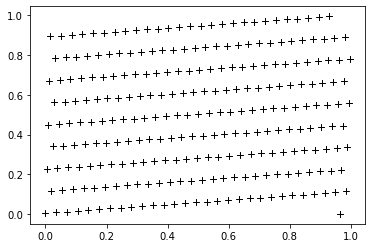

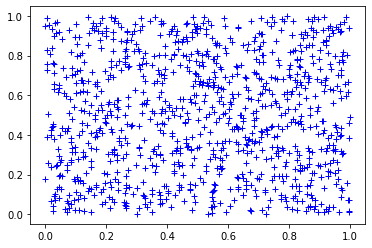

In [2]:
# implementación Paez-Landau fig 5.1
# c= 1; a= 4; M= 9; r1= 3 # secuencia 1
a,c,M,r1 = 57,1,256,10    # secuencia 2

for i in range(1000):
    r2 = (a*r1+c)%(M)
    x, y = r1, r2
    r1 = r2
    
    figure(1)
    plot(x/M,y/M,"k+") # datos normalizados en [0,1), note que 1 nunca se genera
    
    figure(2)
    plot(rand(),rand(),"b+")

En general, todos los generadores de números seudoaleatorios se limitan a generar distribuciones uniformes en el intervalo $[0,1)$, entonces ¿cómo generar otras distribuciones a partir de esta?, las siguientes secciones explican como:


### Distribución uniforme
Para generar una distribución uniforme en $[a,b)$ se hace un mapeo lineal

$$x = a+(b-a)r$$

que sigue distribución

$$f(x)=\frac{1}{b-a}, \quad\text{para}\quad  a<x<b$$

Note que el mapeo anterior de $x$ se puede también calcular usando al función cumulativa en $[a,x]$ si se tiene en cuenta que $F(x)=r$ es un número aleatorio entre cero y uno, entonces se puede despejar $x$ como función de $r$ lo recobra la expresión anterior para $x$. 

**Tarea**, haga la integral y demuestre el enunciado anterior.

### Distribución exponencial
Partículas neutrales como los fotones viajan en linea recta entre los puntos de interacción con la materia, la distancia media entre estos puntos se conoce como *trayectoria libre media*, y esta sigue una distribución exponencial que se define por

$$f(x) = \frac{1}{\lambda}e^{-\frac{x}{\lambda}}$$ 

En este caso, $\lambda=1/\sigma$, es el inverso de la sección eficaz (cm$^{-1}$), que es una medida de la interacción entre partículas lanzadas contra un centro dispersor (punto de interacción). La idea es simular la generación de estas partículas de acuerdo a esta distribución exponencial.
En general, para generar números aleatorios con distribución exponencial 
tal que $0<x<\infty$ usamos la formula

$$x = -\lambda\ln(1 -r_i).$$

Esta fórmula se obtiene a partir de la función de distribución 

$$F(x)=r_i=\int_0^x \frac{1}{\lambda}e^{-\frac{x}{\lambda}} dx.$$

pues $F(x)$ garantiza números uniformemente distribuidos en el intervalo $[0,1]$. 

**Tarea**, demostrar que de la integral se obtiene la formula anterior para $x$. 

**Ejemplo**:

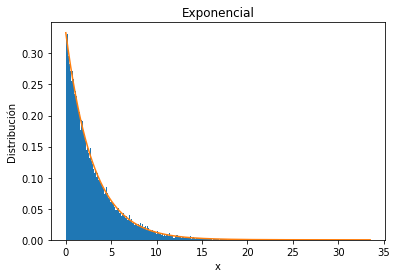

In [3]:
n =100000
l=3
# 1) exponencial usando las librerías de python 
plt.figure(1)
plt.title("Exponencial")
plt.xlabel("x")
plt.ylabel("Distribución")

r = random.random(n)
x = -l*log(1-r)
plt.hist(x, bins=1000,density=True)

xi = np.linspace(x.min(), x.max(),1000)
plt.plot(xi,np.exp(-xi/l)/l )
show()
#r.max(), r.min(), x.max(), r.min()

### Distribución gaussiana
Hay varias maneras de generar una distribución gaussiana: con el método de Box-Muller, por teorema central del límite y por el método de Von Neumann:

**1)** [**El método de Box-Muller**](https://es.wikipedia.org/wiki/M%C3%A9todo_de_Box-Muller):
sea $r_1$ y $r_2$ variables aleatorias independientes uniformemente distribuidas en el intervalo $[0, 1)$ entonces

$$x =\sqrt{-2 \ln r_1} \cos(2 \pi r_2)$$

tiene distribución gaussiana. En python existen dos funciones que generan números con distribución gaussiana a partir de la fórmula de Box-miller,
```python
x = numpy.random.randn(n)  # distribución con desviación estándar (sigma) uno y centrada en cero.
x = numpy.random.normal(size=n) # similar
```
como $x$ tiene desviación estándar de uno y valor medio cero, si se quiere generar un número $x$ con desviación estándar 
$\sigma$ y valor medio $\mu$ se hace el escalamiento,

$$r=\mu+x\sigma.$$

La operación contraria, $x=\frac{r-\mu}{\sigma}$, se conoce como *estandarización*.
Nota, no confundir `randn()` con `rand()` que genera una distribución uniforme.

**Ejemplo**:

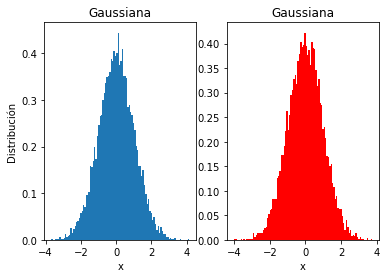

In [4]:
import matplotlib.pyplot as plt
from numpy.random import normal

n =10000
# 1) Gaussiana usando las librerías de python 
# subplot(fila,columna,posición), ejem: "234" es 2x3 grid, 4th subplot.
plt.subplot(121) #(211)
plt.title("Gaussiana")
plt.xlabel("x")
plt.ylabel("Distribución")

x = normal(size=n)
plt.hist(x, bins=100,density=True)


# 2) Gaussiana usando el método de Box-Muller
plt.subplot(122) #(211)
plt.title("Gaussiana")
plt.xlabel("x")
#plt.ylabel("Distribución")

r1= random.random(n)
r2= random.random(n)
x = sqrt(-2*log(r1))*cos(2*pi*r2) # x es un array

plt.hist(x, bins=100,density=True, color='r')
show()

**Ejercicio:** reescale a diferentes valores de $\sigma$ y $\mu$ estos gráficos.

**2) Teorema central del límite**:
Este teorema da una forma simple de generar números con distribución gaussiana (aunque menos eficiente). El teorema dice que si una secuencia de números ${r_i}$ generados de manera independiente entre sí entonces su suma 

$$x = \sum_{i=1}^Nr_i$$

sigue una distribución gaussiana

$$f(x) = \frac{1}{\sqrt{2\pi\sigma^2} } \; e^{ -\frac{(x-\mu)^2}{2\sigma^2} },\,\, \mu=N\langle r\rangle ,\,\, \sigma^2=N(\langle r^2\rangle -\langle r\rangle ^2).$$

Para obtener la distribución, se repite este calculo $M$ veces y así encontrar M valores $x_j$ donde cada $x_j$ es suma $N$ valores $r_i$.

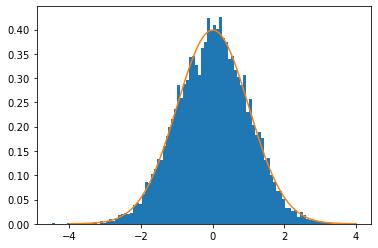

In [5]:
# Gaussiana usando el teorema del límite central
M = 10000
N = 1000

#-- gaussiana teorema del central del límite --
h=zeros(M)
for i in range(M):
    # generar N eventos con distintas distribuciones:  
    # r=rand(N)+randn(N)+exponential(size=N)+poisson(1,size=N)

    r=random.rand(N) # generar N eventos con dist uniforme  
    x=sum(r)         # suma de eventos independientes
    h[i]=x           # guardar x en histograma h
    
h=( h - h.mean() )/h.std() # estandarización 
hist(h,bins=100, density=True)    

#-- función de distribución gaussiana teórico -
f = lambda t: 1./sqrt(2*pi)*exp(-t**2./2.) 

t = linspace(-4,4,N)
plot(t,f(t))
show()

**3) Método de Von Neumann**: 
considere un rectángulo de area $(b-a)W$ con $W=f_{max}$, genere puntos aleatorios $(r_i,y_i)$, si caen bajo la curva gaussiana $f(x)$ se aceptan los $r_i$, sino se rechazan, de esta forma los $r_i$ aceptados tienen distribución gaussiana.
Aunque este método genera números aleatorios con distribución gaussiana  no es eficiente, pues al rechazar se pierden muchos números y tiempo de computación.

**Tarea**: implemente el método de Von Neumann para generar una distribución gaussiana y compare a los métodos anteriores.

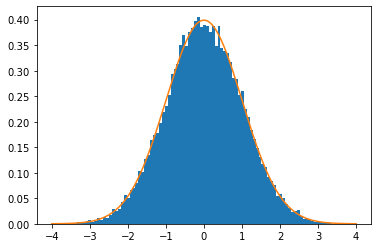

In [6]:
# *** Método de Von Neumann, genera r con dist gaussiana ***
M = 100000
W = 0.4   # fmax para función gaussiana.

#-- función de distribución gaussiana teórico --
f = lambda t: 1./sqrt(2*pi)*exp(-t**2./2.) 

r = -4 + rand(M)*8 # generar r en [-4,4]
y = W*rand(M)      # generar y en [0, W] 
h = []
for i in range(M):
    if y[i]<=f(r[i]): h=append(h,r[i])
                                                                                                     
hist(h, bins=100, density=True)
plot(t,f(t))
show()

En experimentación cuando se mide una cantidad hay un error asociado a ella, el error es dado por la desviación estándar, así, sea $y(x)$ la cantidad a calcular, entonces del experimento (repetido $n$ veces para un valor fijo de $x$) se encuentra que el valor de $y$ debe ser, 

$$y=\mu\pm\sigma,$$ 

si los errores son independientes entre sí, entonces el error total será gaussiano por el teorema central del límite; esto de debe hacer para cada valor de $x$. Por ejemplo si $T=y(x)$ representa la temperatura en un punto $x$ de una barra entre dos reservorios de calor (un extremo a $0^\circ$ C y el otro $100^\circ$ C), si se mide la temperatura en el punto medio $n$ veces, esta será distinta a cada medida de modo que podemos decir que $T(x)=\mu(x)\pm\sigma(x),$ el error será la suma de muchos errores independientes y por lo tanto gaussiano (fluctuaciones en la electricidad, resistencias no uniformes, mal aislamiento de la nevera, por lo que los reservorios no mantienen la temperatura constante, factores ambientales, corrientes de aire, termómetro descalibrado, etc).

**Ejemplo**: el siguiente código agrega ruido gaussiano a una función, note que la función $\mu=f(x)$ representa el valor medio,

 $$
 y = f(x) + \epsilon,\\
 y = (x^2+2x+1) + \epsilon,
 $$
 
 el ruido se calcula generando un número con desviación estándar $\sigma=10$ y centrado en cero (recuerde que `randn()` genera distribuciones centradas en cero y con desviación estándar igual a uno): 

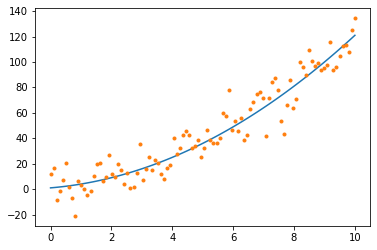

In [7]:
n = 100                # puntos a graficar
x = linspace(0,10,n)   # intervalo de graficación

for i in range(1):
    y = x**2 + 2*x + 1     # valor medio como función de x
    error = randn(n)*10    # error gaussiano con desviación standar de sigma=10
    
    plot(x,y)              # graficar valor medio f(x)
    plot(x,y + error, '.') # error 

esta es una manera de simular el ruido que se genera en un experimento, donde podríamos afirmar que el evento se describe por la función $f(x)$ y se desvía $\epsilon$ de este valor, en general tendríamos que nuestra cantidad física se encuentra en el intervalo $[f(x)-\epsilon,f(x)+\epsilon]$. En conclusión, la desviación estándar corresponde a los errores estadísticos.

**Ejercicio**: a) cambie el valor de $\sigma$ y vea que pasa, b) Grafique otras funciones con ruido.

In [8]:
# Hacer tarea

### Distribución de Poisson
Para generar números enteros $k$ con distribución de Poisson, 
$$f(k) = e^{-\mu}\frac{\mu^k}{k!},$$
donde $k = 0, 1, 2, ...$ veces en el intervalo, hacemos los siguientes pasos:

 1. Inicialize: $k = 0, A = 1$.
 2. Genere un número aleatorio uniforme $u$ en $[0,1]$, defina $A = uA$.<br> 
    Si $A \leq \exp(−\mu)$ acepte $k$ y pare, si no:
 3. Incremente $k = k + 1$ y regrese al paso 2.
 
Este algoritmo nos da la probabilidad de observar $k$ eventos en un intervalo dado:

0.0 9.0


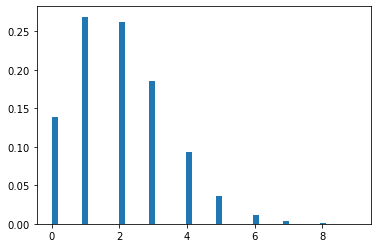

In [9]:
#   *** Distribución de Poisson  *** 

n  = 10000 # numero total de eventos
mu = 2     # rata de eventos(num promedio de eventos por intervalo)

h=[]
for i in range(n):
   k=0; A=1 
   while 1:  
      u = random.random()  # generar num aleatorio en [0,1]
      A = u*A            
    
      if (A <= np.exp(-mu)):
        h = np.append(h,k) # acepte k
        break              # pare
      else:
        k = k + 1          # incremente k
print(h.min(),h.max()) 

plt.hist(h,bins=50,weights=np.ones(n)/n)#, normed=True) 
show()

**Tarea**: En este caso el tiempo de cómputo del algoritmo incrementa linealmente con $n$, otra alternativa es implementar el método de Von Neumann para generar la distribución de poisson, hágalo y compare los tiempos de cómputo con método anterior.

In [10]:
# Hacer tarea

<a id='Métodos_de_monte_carlo'></a>
# Métodos de monte carlo en física

### Camino aleatorio
<!---
$$\begin{align}
\mathbf{R}=\mathbf{r}-\mathbf{r}_0=&\,\Delta\mathbf{r}_1+\Delta\mathbf{r}_2+...,+\Delta\mathbf{r}_N\\
=&\sum_{i=1}^N \Delta\mathbf{r}_i.
\end{align}
$$
si se toma el producto punto $(\mathbf{r}-\mathbf{r}_0)^2$, y se considera que el momimiento es en 2D con $\mathbf{r}=x\mathbf{\hat i}+y\mathbf{\hat j}$, e igualmente para cada $\Delta\mathbf{r}_i$
--->
El camino aleatorio en 2 dimensiones se genera a partir de generar pasos consecutivos en el intervalo $[-1,1]$. (ver libro Landau-Paéz para teoría).

Código que simula el movimiento aleatorio de un partícula en 2D:

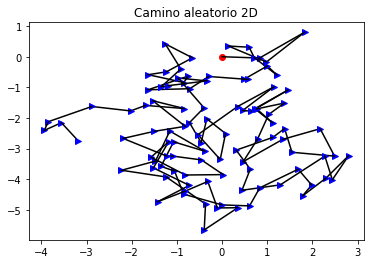

In [11]:
N = 100         # pasos
x=0;  y=0       # posición paso actual
x0=0; y0=0      # posición paso anterior
plot(x0,y0,"ro")# origen

for i in range(N):
   x += ( random.rand() - 0.5 )*2. # -1 =< x =< 1
   y += ( random.rand() - 0.5 )*2. # -1 =< y =< 1
   
   plot([x0, x],[y0, y],'k-')
   plot(x,y,"b>")
   #plt.arrow(x0, y0, x-x0, y-y0,head_width=0.2, head_length=0.3, fc='k', ec='b')
   x0=x; y0=y
plt.title("Camino aleatorio 2D")
show()

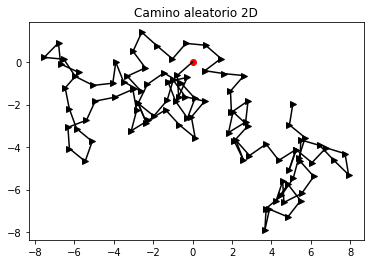

In [12]:
N = 100         # pasos
x=0;  y=0       # posición paso actual
x0=0; y0=0      # posición paso anterior
plot(x0,y0,"ro")# origen
scalar = 1
for i in range(N):
   dx = ( random.rand() - 0.5 )*2. # -1 =< x =< 1
   dy = ( random.rand() - 0.5 )*2. # -1 =< y =< 1
   # normalizar
   norm = np.sqrt(dx**2 + dy**2)

   x += scalar*dx/norm 
   y += scalar*dy/norm
    
   plot([x0, x],[y0, y],'k-')
   plot(x,y,"k>")
   #plt.arrow(x0, y0, x-x0, y-y0,head_width=0.2, head_length=0.3, fc='k', ec='b')
   x0=x; y0=y
plt.title("Camino aleatorio 2D")
show()

**Tarea**: Calcule el desplazamiento cuadrático de la partícula
$${\bf R}^2$$
donde se define
$${\bf R} =\Delta {\bf r}_1+\Delta {\bf r}_2,\dots,\Delta {\bf r}_N$$
como la suma de $N$ pasos aleatorios.

### Decaimiento Exponencial

Código python para la simulación del decaimiento exponencial (ver libro Landau-Paéz para teoría):        

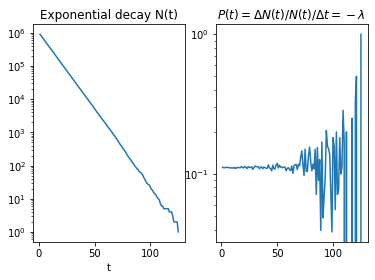

In [13]:
# Decay.py spontaneous decay simulation
import matplotlib.pyplot as plt
import numpy as np

lamda = 1.e-1 # Decay constant
N = 1000000
t = 0
tt = []
Nt = []
DeltaNt = []

while N > 1:    
    DeltaN = 0
    for i in range(N):
        if ( np.random.rand() < lamda ): DeltaN += 1

    t += 1.
    N -= DeltaN
    
    tt= np.append(tt,t)
    Nt= np.append(Nt,N)
    DeltaNt = np.append(DeltaNt,DeltaN)
    
plt.subplot(121) #(211)
plt.semilogy(tt,Nt)
plt.title("Exponential decay N(t)")
plt.xlabel("t")

plt.subplot(122) #(212)
plt.semilogy(tt,DeltaNt/Nt) # probability P = N/dN/dt = -lambda
plt.title(r"$P(t) = \Delta N(t)/N(t)/\Delta t = -\lambda$")
show()

### Procesos de Poisson

Considere las siguientes situaciones físicas:
1. Se quiere calcular la eficiencia en el número fotones que llegan a un detector (por ejemplo el de un telescopio) cada intervalo de tiempo.
2. Suponga que en mil años se observan 100 supernovas en una región del universo y se desea saber el tiempo que pasa entre dos supernovas y con que probabilidad.
3. Se sabe que en la tierra ocurren aproximadamente 13000 terremotos al año, es decir uno cada ~40 min, ¿si ocurre uno ahora cuando ocurrirá el próximo?
4. Se quiere calcular los tiempos de difusión de una partícula en un medio.

Todos estos problemas se refieren a situaciones donde se puede llevar un conteo de un número determinando de eventos que ocurren a determinada frecuencia en el tiempo pero que son de naturaleza aleatoria (sin una estructura), a esta clase de problemas se le conoce como [procesos de poisson](http://preshing.com/20111007/how-to-generate-random-timings-for-a-poisson-process/). 

En general *los procesos de poisson se dan cuando se tienen eventos raros que ocurren individualmente  y de manera aleatoria* (tienden a ocurrir a una rata promedio constante cuando se ven en grupo y no hay memoria o correlación entre los eventos). 
Por ejemplo, en un experimento se obtienen $10000$ datos cada hora, es decir que en promedio se obtienen $\lambda = 10000/(3600\text{ s })\approx2.777$ s$^{-1}$  datos cada segundo, ósea que cada evento se genera en promedio cada $3600/10000=0.36$ s. En general se puede definir la frecuencia como,

$$\lambda=\frac{\text{número de eventos}}{\text{tiempo total}},$$ 

que da una medida de la frecuencia de los eventos o el promedio de rata de eventos por unidad de tiempo. 
Ahora hagamos la siguiente pregunta ¿Cuál es la probabilidad $P$ de tener un evento en los próximos $2.0$ s si ha ocurrido uno justo ahora? Para responder la pregunta se hace uso de la función de distribución de poisson,

$$F(N)=\sum_{k=0}^Ne^{-\mu}\frac{\mu^{k}}{k!},$$ 

que da la probabilidad de observar un número de eventos igual o menor que $N$ para un tiempo $t$. Como los procesos de poisson son procesos que ocurren en el tiempo, la probabilidad individual de que ocurra un evento en un intervalo de tiempo $\Delta t$ es dada por $p=\lambda \Delta t$ y si hay $N$ procesos en un tiempo $t$ entonces $\mu=Np=N\lambda \Delta t$  lo cual da, 

$$\mu=\lambda t.$$

De la función de distribución, la probabilidad de no tener ningún evento en $\Delta t$ se da cuando $N=0$ o $F(0)=e^{-\lambda \Delta t}$ y la probabilidad de que si ocurra es, $P(\Delta t)=1-F(0),$ lo cual da que, 

$$ \boxed{P(\Delta t) = 1 - e^{-\lambda \Delta t}.}$$

Se infiere de esta fórmula que a medida que pasa el tiempo la probabilidad tiende a uno, entonces la pregunta no es si el evento ocurrirá o no, sino cuándo ocurrirá. Así, 

$$P(2.0 s)= 1 - e^{-2.777\times 2}\approx0.996,$$

es la respuesta. Si se despeja el tiempo de esta fórmula y recordamos que $F$ tiene valores uniformemente distribuidos en $[0,1]$, entonces, para generar el tiempo en el cual ocurrirá un proceso de poisson, 
se genera un número aleatorio $r_i$ entre $[0,1)$ y el tiempo se calcula como,

$$\boxed{\Delta t = \dfrac{-\ln(1- r_i)}{\lambda}.}$$

Note que se puede poner $r_i$ en vez de $(1-r_i)$, pero esta última es más conveniente debido a que evita pasar el cero al logaritmo (pues el generador de $r_i$ no considera el 1). 
En el siguiente ejemplo de python el primer plot muestra la naturaleza exponencial del sistema, el segundo la linea de tiempo entre $10$ eventos consecutivos y también se muestra que para $N$ eventos consecutivos, 

$$\lambda \approx\frac{1}{N}\sum_{i=1}^N\dfrac{-\ln(1- r_i)}{(1/\lambda)}.$$ 

**Ejemplo**: Programa python que simula la ocurrencia de eventos con tiempo $\Delta t_i$ como función de la rata $\lambda$ (note que en la  suma se usa el inverso de $\lambda$):

The sum should be approx lambda: 2.7777777777777777 2.936180560411884


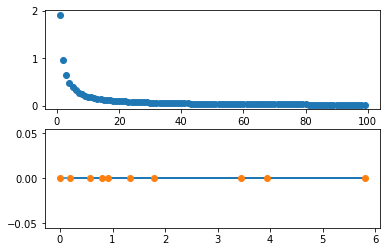

In [14]:
# Poisson_process.py
# To get time for obtaining an event if given the rate lambda.
# Note that we cannot pass zero to np.log(), but we avoid that 
# by subtracting the result of random.rand():

steps = 100
lamda =  10000/3600 # fecuency of events

def delta_t(lamda):
    return -log(1.0 - random.rand())/lamda # rate Parameter

#------------ 1) plot showing exponential behavior -----------
plt.subplot(211) #(121)
t=arange(1,steps)
plot(t,delta_t(t),'o') 

#---------2) plot of the N consecutive delta t steps ---------
plt.subplot(212) #(122)
t=[]
for i in range(10):
    t.append(delta_t(1/lamda))

plt.plot(t, zeros(10)) 
plt.plot(t, zeros(10), 'o')

#-- tests to verify that the average time returned is lamda --
Sum_steps = sum([delta_t(1/lamda) for i in range(steps)])/steps

print ("The sum should be approx lambda:",lamda, Sum_steps)

**Tarea**: Note que cada vez que se corre el programa Poisson_process.py las curvas son diferentes, verifique esto con un bucle "for" de 5 plots en el mismo gráfico (para observar mejor las lineas de tiempo en el segundo gráfico, incremente en 1 el eje $y$ en a cada plot).

**Tarea**: Calcule las ratas por unidad de tiempo para los ejemplos 2) y 3) dados al comienzo del tema y calcule los tiempos usando el algoritmo anterior.

**Tarea**: considere el ejemplo de caminos aleatorios donde se generan pasos con un $\Delta t$ constante (se puede pensar esto como un proceso de difusión de una partícula (o partículas) en un medio homogéneo a una rata constante de $\lambda=0.1$ s$^{-1}$):
  + Cambie el algoritmo y a cada paso asigne un tiempo $\Delta t_i$ con distribución de poisson.
  + Considere mil partículas cada una con un camino aleatorio y muestre que $\langle R^2\rangle$ vs $t$ es una recta (la pendiente en física se interpreta como proporcional al coeficiente de difusión). Nota, considere cada camino formado por 2000 pasos y a $\bf R$ la suma vectorial de estos pasos.
  + Verifique la [hipótesis ergódica](https://en.wikipedia.org/wiki/Ergodic_theory#Ergodic_theorems): para una sola partícula repita mil veces el camino aleatorio y muestre que $\langle R^2\rangle$ vs $t$ es otra vez una recta. Igualmente, considere cada camino formado por 2000 pasos y a $\bf R$ la suma vectorial de estos pasos (en este caso considere $\Delta t=1$).

### Regresión lineal: mínimos cuadrados 
Normalmente en experimentos se quiere comprobar si los datos obtenidos se ajustan a un modelo teórico, así se propone una función $g(x_i,\{a_1,\dots,a_{N_p}\})$ con $N_p$ parámetros $\{a_1,\dots,a_{N_p}\}$ teóricos a ajustar según $N_D$ datos experimentales $(x_i,y_i\pm\sigma_i)$ (donde los $\sigma_i$ son el error de los $y_i$; si los errores no son dados se toma $\sigma_i=1$). 
Un método común usado es el de mínimos cuadrados el cual para encontrar la curva que mejor se ajuste a los $N_D$ datos $(x_i,y_i\pm\sigma_i)$ calcula el error elevado  al cuadrado, que se define como la suma de datos obtenidos menos función teórica propuesta evaluada a cada punto $x_i$, ósea

$$\chi^2=\sum_{i=1}^{N_D}\left(\frac{y_i-g(x_i,\{a_1,\dots,a_{N_p}\})}{\sigma_i}\right)^2,$$

para encontrar los parámetros $\{a_i\}$ que mejor se ajusten, se minimiza el error

$$\frac{\partial \chi^2}{\partial a_k}=0 \iff\sum_{i=1}^{N_D}\left(\frac{y_i-g(x_i,\{a_1,\dots,a_{N_p}\})}{\sigma_i}\right)\frac{\partial g}{\partial a_k}=0$$

Esto da un sistema de $N_p$ ecuaciones donde se deben encontrar los valores de $N_p$ parámetros $a_k$. Si la función es $g(x) = a_1 + a_2x $ se obtiene un sistema de 2 ecuaciones a resolver, igualmente si la función es $g(x) = a_1 + a_2x + a_3x^2$ el sistema tiene 3 parámetros a encontrar. En general, en el caso de funciones polinomiales las ecuaciones son lineales, pero si las ecuaciones son exponenciales, $g(x)=be^{ax}$ o $g(x)=bx^a$), o de otra forma, por ejemplo $g(x)=\frac{a_1}{(x^2-a_2^2)^2+a_3^2}$, se obtienen sistemas no lineales de ecuaciones y solo se pueden obtener valores aproximados de los valores ${a_k}$. El ajuste se considera bueno si $\chi^2\approx N_D-N_p$.

La siguiente función numpy se puede usar para mínimos cuadrados:

    numpy.linalg.lstsq(a, b, rcond=-1)
 
**Fiteo de mínimos cuadrados con una función cuadrática**:
El siguiente algoritmo calcula el fiteo de mínimos cuadrados para una parábola, 

$$g(x) = a_1 + a_2x + a_3x^2$$

Como hay 3 parámetros $a_i$, esto da un sistema de 3 ecuaciones (ver el libro de Landau-Paéz para la teoría, cap 8), 

$$ Sa_1 + S_xa_2 + S_{xx}a_3 =S_y,$$ 
$$ S_xa_1 + S_{xx}a_2 + S_{xxx}a_3 =S_{xy},$$
$$ S_{xx}a_1 + S_{xxx}a_2 + S_{xxxx}a_3 =S_{xxy};$$

entonces se resuelve el sistema lineal de ecuaciones $A{\bf a} =\bf b$. 
Note que este algoritmo también sirve si $g(x) = a_1 + a_2x $.
Programa python:

x Matrix via direct
[-3.1539344   5.14202834 -1.40285004]
Fit Parabola Final Results

y(x) = a0 + a1 x + a2 xˆ2
a0 =  -3.1539343996109546
a1 =  5.14202834369396
a2 =  -1.4028500387655354 

 i xi yi yfit 
 0 1.000 0.520 0.5852439 

 1 1.050 0.730 0.6985532 

 2 1.150 1.080 0.9041290 

 3 1.320 1.440 1.1892171 

 4 1.510 1.390 1.4118900 

 5 1.680 1.460 1.5252693 

 6 1.920 1.580 1.5472936 



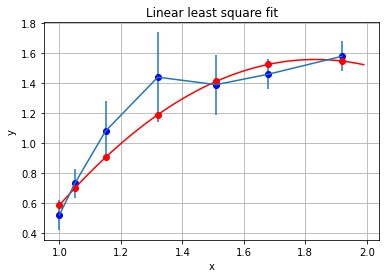

In [15]:
# Fit.py Linear square fit 
# from Landau-Paez book, see chapter 8 
from numpy import *
from numpy.linalg import *
import matplotlib.pyplot as plt


t = arange( 1.0,2.0,0.01)                       # Curve
Nd = 7                                          # Number of data
x = array([1.,1.05,1.15,1.32,1.51,1.68,1.92])   # Given x values
y = array([0.52,0.73,1.08,1.44,1.39,1.46,1.58]) # Given y values
sig=array([0.1,0.1,0.2,0.3,0.2,0.1,0.1])        # errorbar lenghts

plt.plot( x , y ,'bo') # Plot data 
plt.errorbar(x,y,sig)  # Plot error bars
plt.title('Linear least square fit') 
plt.xlabel( 'x' ) 
plt.ylabel( 'y' )
plt.grid( True )

A = zeros((3,3))
bvec = zeros((3,1))
ss = sx = sxx = sy = sxxx = sxxxx = sxy = sxy = sxxy = 0.

for i in range(Nd):
   sig2 = sig[i]*sig[i]   
   ss  += 1./sig2;          sx += x[i]/sig2;        sy += y[i]/sig2
   rhl  = x[i]*x[i];       sxx += rhl/ sig2;      sxxy += rhl*y[i]/sig2
   sxy += x[i]*y[i]/sig2; sxxx += rhl*x[i]/sig2; sxxxx += rhl*rhl/sig2

A = array([[ss,sx,sxx],[sx,sxx,sxxx],[sxx,sxxx,sxxxx]])
bvec = array([sy,sxy,sxxy])

ai = solve(A, bvec)   # Solution via elimination

print('x Matrix via direct')
print(ai)
print('Fit Parabola Final Results\n')
print('y(x) = a0 + a1 x + a2 xˆ2') 
print('a0 = ' , ai[0])
print('a1 = ' , ai[1])
print('a2 = ' , ai[2], '\n')
print(' i xi yi yfit ')

for i in range(Nd):
    s = ai[0] + ai[1]*x[i] + ai[2]*x[i]*x[i]
    print(" %d %5.3f %5.3f %8.7f \n" %(i, x[i] , y[i] ,s) )

# Red line is the fit, red dots the fit saty[i]
curve  = ai[0] + ai[1]*t + ai[2]*t**2.
points = ai[0] + ai[1]*x + ai[2]*x**2.
plt.plot(t, curve, 'r' , x , points , 'ro')

plt.show()

### Ley de grandes números
Considere el valor promedio de $n$ cantidades

$${\overline {X}}_{n}={\frac {1}{n}}(X_{1}+\cdots +X_{n}) $$

La ley de grandes números dice que este valor converge al valor esperado $\mu$ conforme $n$ tiende a infinito, es decir, 

\begin{matrix}{}\\
{\overline {X}}_{n}\,\to \,\mu \qquad {\textrm {para}}\qquad n\to \infty .\\{}
\end{matrix} 

Por ejemplo, en valor esperado en el lanzamiento de un dado es dado por

$${\frac{1+2+3+4+5+6}{6}}=3.5$$ 

Si se lanza el dado muchas veces y se calcula ${\overline {X}}_{n}$, vemos que este valor tiende a $3.5$ conforme $n$ crece. Igual la probabilidad, esta tiende a $1/6\approx0.16667$. Veamos esto en el siguiente experimento numérico:

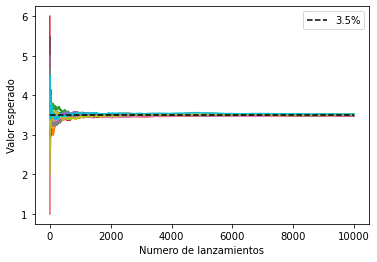

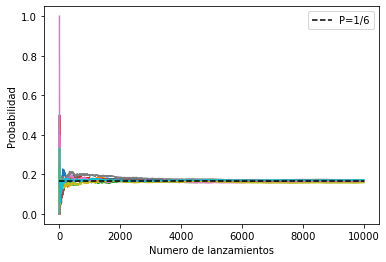

In [16]:
#------------ LEY DE GRANDES NÚMEROS---------------------------
# Aquí se aplica la ley de grandes números al lanzamiento de un 
# dado (ejemplos 1. y 2.).

import numpy as np
from matplotlib.pyplot import *

## --------------------1) EJEMPLO -----------------------------
# El valor esperado de lanzar un dado n veces
# tiende a 3.5 a medida que n se hace grande:

figure(1)

n = 10000             # max numero de lanzamientos
x = np.arange(1,n+1)  # eje x
for i in range(10): # repetir 10 veces
  r = np.random.randint(1,7, size=n) # array aleatorio en [1,6] 
  p = np.cumsum(r)/x # suma cumulativa 
  plot(x,p)         

plot([0,n],[3.5,3.5],'k--',label='3.5%') # valor limite

plt.xlabel("Numero de lanzamientos")
plt.ylabel("Valor esperado")
legend()

# --------------------2) EJEMPLO ------------------------------
# Calculo de probabilidad a medida que n se hace grande:
figure(2)

prob = 1/6. # probabilidad en un dado: 0.16666667
for i in range(10): # repetir 10 veces
  r = (np.random.rand(n) < prob).astype(np.int32)
  p = np.cumsum(r)/x
  plot(x,p)         

plot([0,n],[prob,prob],'k--',label='P=1/6') # valor limite

plt.xlabel("Numero de lanzamientos")
plt.ylabel("Probabilidad")
legend()


#### Ejemplo
Lanzamiento de moneda.

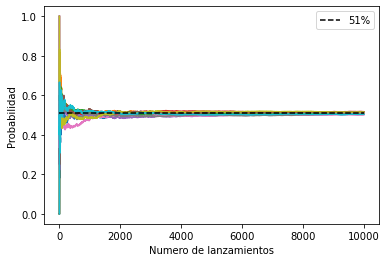

In [17]:
# --------------------3) EJEMPLO ------------------------------
# Ley de grandes números para lanzamientos de moneda con prob 
# de 51% que caiga cara y 49% sello:
figure(3)

Prob = 0.51 # Probabilidad que caiga cara
r = (np.random.rand(n, 10) < Prob).astype(np.int32)# matrix aleatoria
p = np.cumsum(r, axis=0)/x.reshape(-1, 1)# suma cumulativa en cada columna
plot(p)     # 10 columnas, cada columna es un grafico
plot([0,n],[Prob,Prob],'k--',label='51%') # valor limite

plt.xlabel("Numero de lanzamientos")
plt.ylabel("Probabilidad")
legend()

**Tarea**:La ley de grandes números tiene aplicación en muchas áreas de la física, por ejemplo en termodinámica 
la temperatura tiende a un valor fijo a medida que 
se incrementa el número de partículas $n$ a densidad constante.
Calcule la temperatura promedio a partir de la energía cinética promedio como función del número de partículas $n$ para un gas a densidad constante $\rho=\frac{nm}{V}=1.0$ unidades, si
$$    E_{\text{k}}={\frac {1}{2}}mv_{\mathrm {rms} }^{2}={\frac {3}{2}}KT,$$
donde $v_{rms}={\sqrt {\langle v^{2} \rangle}}$ y $K=1.38064852\times10^{23}$ J/K es la constante de Boltzmann. 

# Complemento

### Histograma paso por paso
Para hacer un histograma normalmente usamos el comando `plt.hist(h, bins=m)`, aquí se hace un histograma paso a paso:<br>
1) se convierte cada valor de $x$ a índice entero, se resta el mínimo de $x$ para tener indices positivos comenzando en cero y luego se toma la parte entera de dividir por $\Delta x=(x_{max}-x_{min})/m$, esto es,

$\quad i=\text{int}\left(\dfrac {x-x_{min}}{\Delta x}\right)$

índice con valores $i=0,1,2...,m,$ donde $m$ es el número máximo de bins (barras de altura h).<br>
2) Cada valor $x_i$ pertenece al histograma $h_i$, por lo que cada vez que caiga un valor de $x$ en el intervalo $[x,x+\Delta x]$ se incrementa en uno el histograma,

$\quad h_i = h_i + 1$.<br>

Se repiten estos tres pasos para todos los $n$ valores de $x$. Note que el paso 2) genera $m+1$ indices, donde el índice $m$ corresponde al elemento $x_{max}$, por lo que este se debe poner en la barra $h_{m-1}$ pues solo hay  $m$ barras, un truco es simplemente incrementar $x_{max}$ por una fracción (por ejemplo, multiplicar por $1.0001$) en el computo de $\Delta x$ para forzar que $x_m$ quede en $h_{m-1}$.<br>
3) Se discretiza $x$ en fracciones de $\Delta x$ como,

$\quad x_i=i\Delta x = \text{int}\left(\dfrac {x-x_{min}}{\Delta x}\right)\Delta x\quad\longrightarrow\quad$ valor de $x$ a la posición $i$.<br>

Así todo valor de $x$ en el intervalo $[x,x+\Delta x]$, ha sido aproximado por el valor discreto $x_i$.<br> 
4) Finalmente se hace la normalización, para obtener la densidad de probabilidad,

$\quad p_i=\dfrac{h_i}{n}\quad\longrightarrow\quad f(x_i)=\dfrac{h_i}{n \Delta x}=\dfrac{p_i}{\Delta x}$.

<BarContainer object of 100 artists>

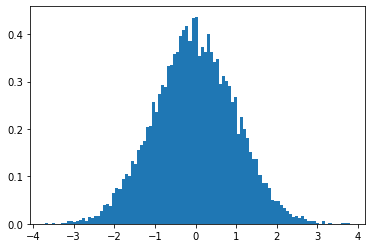

In [18]:
# histograma implementación:
n = 10000 
bins = 100 
h = zeros(bins) 
x = randn(n) 
delta = (1.0001*x.max() - x.min())/bins

for i in range(n): 
    xi = int((x[i]-x.min())/delta)
   # if xi == bins: xi = xi-1, # xi produce m+1 bins, pero más eficiente 
    h[xi] += 1                 # multiplicar por 1.0001 el xmax en delta.
        
xi = arange(x.min(), x.max(),delta)     
# plot(xi,h/(n*delta))
bar(xi,h/(n*delta), width=delta) 

Código del teorema central del límite sin normalización:

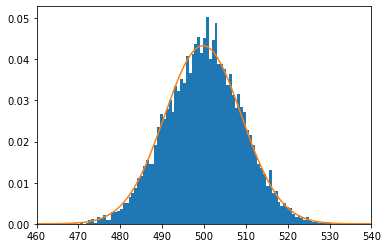

In [19]:
#%pylab inline
# Gaussiana usando el teorema del limite central (sin standarizar)
M = 10000
N = 1000
random.seed(23156)# semilla para generar la misma dist siempre

#-- gaussiana teorema del central del limite --
h=[]
for i in range(M):
    r=random.rand(N)
    x=sum(r)
    h=append(h,x)
    
hist(h,bins=100, density=True)    

#-- función de distribución gaussiana teórico -
x = N*r.mean()       # valor medio 
s = 2.*N*r.std()**2. 
f = lambda t: 1./sqrt(pi*s)*exp(-(t - x)**2./s) 

t = arange(0.0,N,0.001*N)
plot(t,f(t))
xlim(.46*N,.54*N)
show()

Lista de distribuciones en python: [routines.random](https://docs.scipy.org/doc/numpy-1.15.0/reference/routines.random.html)

`numpy.random.standard_t(df, size=None)`
Draw samples from a standard Student’s t distribution with df degrees of freedom:
$P(x, \mathit{df}) = \frac{\Gamma\left(\frac{\mathit{df}+1}{2}\right)}{\sqrt{\pi d\!f}\, \Gamma\left(\frac{\mathit{df}}{2}\right)}\Bigl( 1+\frac{x^2}{\mathit{df}} \Bigr)^{-(\mathit{df}+1)/2}$

`numpy.random.gamma(shape, scale=1.0, size=None)`
Draw samples from a Gamma distribution.
$p(x) = x^{k-1}\frac{e^{-x/\theta}}{\theta^k\Gamma(k)}$


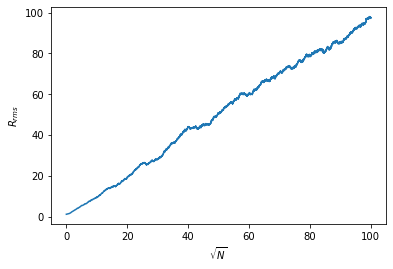

In [20]:
# 1) *** Camino aleatorio (random walk) ***
N = 10000    # número de pasos por trayectoria
M = 100      # promedio sobre M trayectorias
R = zeros(N) 

for j in range(M):
    x = 0. 
    y = 0. 
    for i in range(N): 
        x    += (rand() - 0.5)*2.*2.**.5 
        y    += (rand() - 0.5)*2.*2.**.5 
        R[i] += sqrt(x*x + y*y) 

rootN = sqrt(arange(N))          
plot(rootN, R/M)
ylabel(r'$R_{rms}$')
xlabel(r'$\sqrt{N}$')
show()

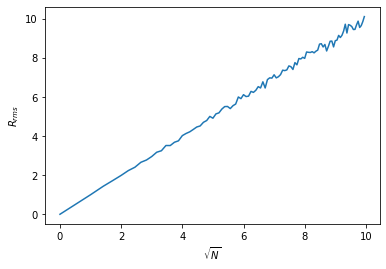

In [21]:
# 2) *** Camino aleatorio versión 2 (más lento) ***
Nmax = 100       # pasos
M = 1000         # promedio sobre M trayectorias.

R = zeros(M)
Rrms = zeros(Nmax)

for N in range(Nmax):
    for k in range(M):

        # ---- una trayectoria -----------------------
        x=0;  y=0      # posición paso actual
        for i in range(N):
            xi = (rand() - 0.5)*2.     # -1 =< x =< 1
            yi = (rand() - 0.5)*2.     # -1 =< y =< 1
            norm = (xi*xi + yi*yi)**.5 # normalización
            x += xi/norm
            y += yi/norm
        # --------------------------------------------
        R[k] = x*x + y*y # incluye correlaciones <xi*xj>.
        
    Rrms[N] = sqrt(R.mean())
    
N = arange(0,Nmax)
sqrtN = sqrt(N)

plot(sqrtN, Rrms)
ylabel(r'$R_{rms}$')
xlabel(r'$\sqrt{N}$')
show()